In [6]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
import matplotlib.pyplot as plt

## GROUP 13 Lab 02

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

# <u>Problem 2</u>  
## Projectile Motion

### Given

The following parameters are used in the projectile motion analysis:

- **Initial speed of projection**:  
  $$
  v_0 = 100 \,\text{m/s}
  $$

- **Acceleration due to gravity** (acting in the downward direction):  
  $$
  g = 10 \,\text{m/s}^2
  $$

- **Quadratic air resistance parameter** (acting opposite to the direction of velocity):  
  $$
  \frac{B_2}{m} = 10^{-5} \,\text{m}^{-1}
  $$

- **Initial position of the projectile**:  
  $$
  x(0) = 0, \quad y(0) = 0
  $$

- **Angles of projection considered**:  
  $$
  \theta = 30^\circ,\;45^\circ,\;60^\circ
  $$

### Approach

The motion of the projectile is analyzed by resolving all physical quantities into **horizontal (x)** and **vertical (y)** components. The position, velocity, and acceleration are treated as vector quantities, and **Newton’s second law** is applied independently along each axis.

We first discuss the expected behavior of the system analytically in order to understand the nature of the trajectories. Since the presence of air resistance makes the equations of motion nonlinear, an exact analytical solution is not possible in this case. Therefore, the equations are solved **numerically using Euler’s method**.


### Air Resistance Models

In this problem, **quadratic air resistance** is considered. The drag force is proportional to the square of the speed and is given by:

$$
\vec{F}_{\text{drag}} = -B_2 \, v \, \vec{v}
$$

This form of drag is physically appropriate for objects moving at **moderate to high speeds**, such as projectiles moving through air.

For comparison, **linear air resistance** is sometimes used, where the drag force is proportional to velocity:

$$
\vec{F}_{\text{drag}} \propto -v
$$



# Resolution of Initial Velocity into Components



The initial velocity components are given by:

$$
v_{x0} = v_0 \cos\theta
$$

$$
v_{y0} = v_0 \sin\theta
$$
###Newton’s Second Law with Air Resistance

When air resistance is taken into account, The drag force is given by:
$$
\vec{F}_{\text{drag}} = - B_2 \, v \, \vec{v}
$$
where
$$
v = \sqrt{v_x^2 + v_y^2}
$$

Using Newton’s second law,
$$
m\frac{d\vec{v}}{dt} = \vec{F}_g + \vec{F}_{\text{drag}}
$$

Dividing throughout by the mass $ m $, we obtain the equations of motion.


### ->Equation of Motion Along the x-axis

$$
\frac{dv_x}{dt} = -\frac{B_2}{m}\, v\, v_x
$$

Substituting the given value,
$$
\frac{dv_x}{dt} = -10^{-5}\, v\, v_x
$$


###-> Equation of Motion Along the y-axis

$$
\frac{dv_y}{dt} = -g - \frac{B_2}{m}\, v\, v_y
$$

Substituting the given values,
$$
\frac{dv_y}{dt} = -10 - 10^{-5}\, v\, v_y
$$


### Kinematic Relations

The velocity components are related to position as:
$$
\frac{dx}{dt} = v_x
$$
$$
\frac{dy}{dt} = v_y
$$

These coupled differential equations are solved numerically using Euler’s method.


### <u>Euler’s Method </u>

Euler’s method approximates the solution of an ODE $dy/dt = f(t,y)$ as:

$$
y_{n+1} = y_n + \Delta t \, f(t_n, y_n)
$$





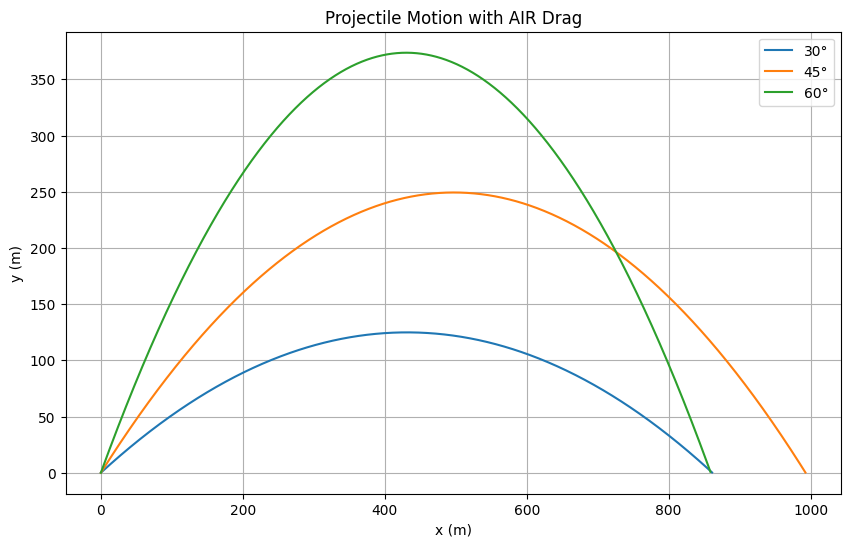

In [8]:
g, v0, B2_m = 10, 100, 1e-5
angles = [30, 45, 60]
dt = 0.01
t = np.arange(0, 30, dt)

def f_drag(t, Y):
    x, y, vx, vy = Y
    v = np.sqrt(vx**2 + vy**2)
    return np.array([vx, vy, -B2_m*v*vx, -g-B2_m*v*vy])

plt.figure(figsize=(10,6))
for angle in angles:
    theta = np.radians(angle) # Convert angle from degrees to radians
    y0 = np.array([0, 0, v0*np.cos(theta), v0*np.sin(theta)])
    sol = euler(f_drag, y0, t) # Solve the ODEs using Euler’s method
    mask = sol[:,1] >= 0  # Keep only points where projectile is above ground
    plt.plot(sol[mask,0], sol[mask,1], label=f'{angle}°')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Motion with AIR Drag')
plt.legend()
plt.grid()
plt.show()


### Without Air Resistance

If $B_2$ = 0, the equations reduce to:

$$
\frac{dv_x}{dt} = 0, \quad \frac{dv_y}{dt} = -g
$$

The motion is **parabolic**, and the horizontal velocity is constant.

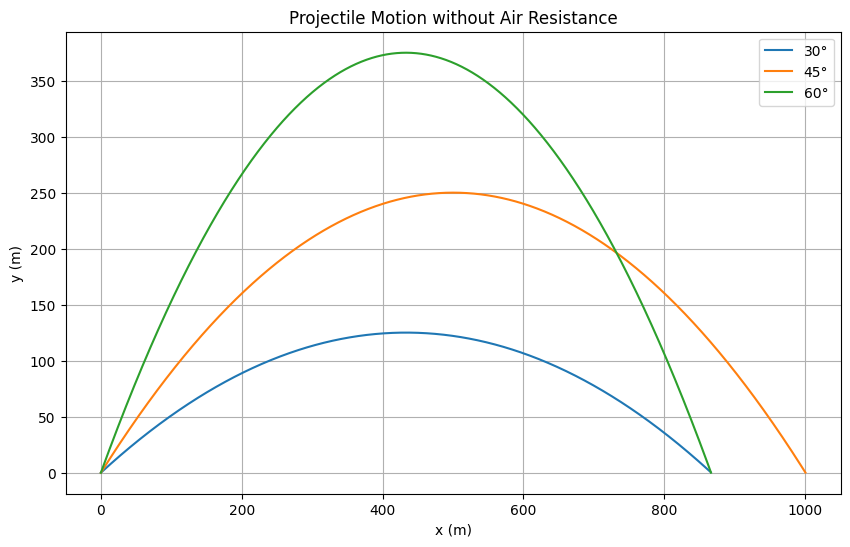

In [9]:
def f_nodrag(t, Y):
    x, y, vx, vy = Y
    return np.array([vx, vy, 0, -g])

plt.figure(figsize=(10,6))
for angle in angles:
    theta = np.radians(angle)
    y0 = np.array([0, 0, v0*np.cos(theta), v0*np.sin(theta)])
    sol = euler(f_nodrag, y0, t)
    mask = sol[:,1] >= 0
    plt.plot(sol[mask,0], sol[mask,1], label=f'{angle}°')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Motion without Air Resistance')
plt.legend()
plt.grid()
plt.show()

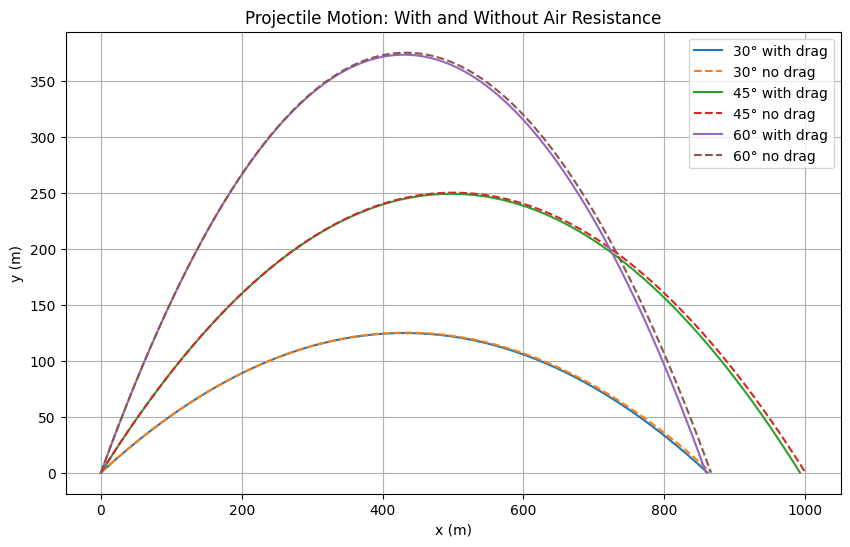

In [11]:
# extra - just comparing both the graphs side by side

plt.figure(figsize=(10,6))

for angle in angles:
    theta = np.radians(angle)
    y0 = np.array([0,0,v0*np.cos(theta),v0*np.sin(theta)])

    sol_drag = euler(f_drag, y0, t)
    mask_drag = sol_drag[:,1] >= 0
    plt.plot(sol_drag[mask_drag,0], sol_drag[mask_drag,1], label=f'{angle}° with drag')

    sol_nodrag = euler(f_nodrag, y0, t)
    mask_nodrag = sol_nodrag[:,1] >= 0
    plt.plot(sol_nodrag[mask_nodrag,0], sol_nodrag[mask_nodrag,1], '--', label=f'{angle}° no drag')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Motion: With and Without Air Resistance')
plt.legend()
plt.grid()
plt.show()


## Observations and Remarks

1. **Effect of Air Resistance**
   - The trajectories with air resistance (solid lines) are shorter in both **range** and **maximum height** compared to the no-drag trajectories (dashed lines).  
   - This is because the quadratic drag force continuously removes kinetic energy from the projectile.

2. **Trajectory Shape**
   - Without drag, the motion is a **perfect parabola** and symmetric about the peak.  
   - With drag, the trajectory is **non-parabolic** and **asymmetric**: the projectile slows down faster in the horizontal direction.

3. **Angle Dependence**
   - The difference between drag and no-drag cases is more noticeable at **higher angles** (e.g., 60°), since the projectile spends more time in the air and loses more energy to air resistance.  
   - Lower angles (e.g., 30°) show less deviation because the flight time is shorter.

4. **Practical Interpretation**
   - Air resistance reduces both horizontal and vertical components of velocity.  
   - The effect is more pronounced at high speeds and long flight times, demonstrating why real projectiles always travel shorter distances than ideal parabolic predictions.

**Conclusion:** Air resistance significantly alters the projectile’s path, reducing range and height, and making the motion asymmetric. The no-drag case represents the idealized parabolic trajectory.
